# 01 — Load USCRN Excel files into a tidy CSV

You should have the following files in `../data/uscrn/`:
- `All_CONUS_Station_Information*.xlsx`  (station metadata: id, lat, lon)
- `USCRN_Precipitation*.xlsx`
- `USCRN_AirTemperature*.xlsx`
- `USCRN_RelativeHumidity*.xlsx`
- `USCRN_SoilTemperature*.xlsx`
- `USCRN_SoilMoisture*.xlsx`

This notebook is **defensive**: it inspects the workbooks first, then runs a
flexible parser. If your layout differs from the assumed one (date column +
one column per station), the inspection cells show you exactly what to tweak.

Output: `../data/uscrn/uscrn_daily_tidy.csv` with columns
`station_id, lon, lat, date, precip, rh, t_air, t_soil, sm`.


In [1]:
import sys, pathlib, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
from utils import CONUS_BBOX, ensure_dirs, find_col

ensure_dirs(ROOT)
DATA = ROOT / 'data' / 'uscrn'
TIDY = DATA / 'uscrn_daily_tidy.csv'
print('looking in', DATA)
print(sorted(p.name for p in DATA.glob('*.xlsx')))


looking in /home/askeladd/Downloads/gnr640_project/data/uscrn
['All_CONUS_Station_Information_V2.xlsx', 'USCRN_AirTemperature_2006_2021.xlsx', 'USCRN_Precipitation_2006_2021.xlsx', 'USCRN_RelativeHumidity_2006_2021.xlsx', 'USCRN_SoilMoisture10cm_2006_2021.xlsx', 'USCRN_SoilTemperature_2006_2021.xlsx']


## Config

In [2]:
YEAR = 2020   # the year you'll grid in notebooks 02-04. Pick one inside 2006-2021.

# File patterns. Adjust if your filenames differ.
PATTERNS = {
    'station_info': 'All_*Station*Info*.xlsx',
    'precip':       'USCRN_*Precip*.xlsx',
    'rh':           'USCRN_*RelativeHum*.xlsx',
    't_air':        'USCRN_*AirTemp*.xlsx',
    't_soil':       'USCRN_*SoilTemp*.xlsx',
    'sm':           'USCRN_*SoilMoist*.xlsx',
}

paths = {}
for key, pat in PATTERNS.items():
    matches = sorted(DATA.glob(pat))
    assert matches, f'no file matching {pat} in {DATA}'
    paths[key] = matches[0]
    print(f'{key:14s} -> {matches[0].name}')


station_info   -> All_CONUS_Station_Information_V2.xlsx
precip         -> USCRN_Precipitation_2006_2021.xlsx
rh             -> USCRN_RelativeHumidity_2006_2021.xlsx
t_air          -> USCRN_AirTemperature_2006_2021.xlsx
t_soil         -> USCRN_SoilTemperature_2006_2021.xlsx
sm             -> USCRN_SoilMoisture10cm_2006_2021.xlsx


## Step 1 — Inspect station info

In [3]:
si_raw = pd.read_excel(paths['station_info'], sheet_name=None)
print('sheets:', list(si_raw.keys()))
si = si_raw[list(si_raw.keys())[0]]
print('shape:', si.shape)
print('columns:', si.columns.tolist())
si.head()


sheets: ['Sheet1']
shape: (234, 4)
columns: ['StationName', 'StationID', 'Lon', 'Lat']


,StationName,StationID,Lon,Lat
0,AK_Fairbanks_11_NE,26494,-147.51,64.97
1,AK_Sitka_1_NE,25379,-135.33,57.06
2,AK_St._Paul_4_NE,25711,-170.21,57.16
3,AK_Utqiaġvik_formerly_Barrow_4_ENE,27516,-156.61,71.32
4,AL_Gadsden_19_N,63857,-85.96,34.29


In [4]:
# Try to auto-detect station-id, lat, lon columns. Override manually if mis-detected.
ID_COL  = find_col(si.columns, 'station name', 'name', 'wban', 'station id', 'station_id', 'station number', 'location', 'id')
LAT_COL = find_col(si.columns, 'latitude', 'lat')
LON_COL = find_col(si.columns, 'longitude', 'lon')
print('ID  ->', ID_COL)
print('LAT ->', LAT_COL)
print('LON ->', LON_COL)
assert ID_COL and LAT_COL and LON_COL, 'override these manually if auto-detection failed'

station_lookup = (si[[ID_COL, LAT_COL, LON_COL]]
                  .rename(columns={ID_COL: 'station_id', LAT_COL: 'lat', LON_COL: 'lon'})
                  .dropna(subset=['lat', 'lon'])
                  .drop_duplicates('station_id'))
station_lookup['station_id'] = station_lookup['station_id'].astype(str).str.strip()
print('stations with coords:', len(station_lookup))
station_lookup.head()


ID  -> StationName
LAT -> Lat
LON -> Lon
stations with coords: 234


,station_id,lat,lon
0,AK_Fairbanks_11_NE,64.97,-147.51
1,AK_Sitka_1_NE,57.06,-135.33
2,AK_St._Paul_4_NE,57.16,-170.21
3,AK_Utqiaġvik_formerly_Barrow_4_ENE,71.32,-156.61
4,AL_Gadsden_19_N,34.29,-85.96


## Step 2 — Inspect one variable file

In [5]:
sample = pd.read_excel(paths['precip'], sheet_name=None)
print('sheets:', list(sample.keys()))
df0 = sample[list(sample.keys())[0]]
print('shape:', df0.shape)
print('first 8 columns:', df0.columns[:8].tolist())
df0.head()


sheets: ['Sheet1']
shape: (5844, 235)
first 8 columns: ['date', 'AK_Fairbanks_11_NE', 'AK_Sitka_1_NE', 'AK_St._Paul_4_NE', 'AK_Utqiaġvik_formerly_Barrow_4_ENE', 'AL_Gadsden_19_N', 'AL_Selma_13_WNW', 'AZ_Elgin_5_S']


,date,AK_Fairbanks_11_NE,AK_Sitka_1_NE,AK_St._Paul_4_NE,AK_Utqiaġvik_formerly_Barrow_4_ENE,AL_Gadsden_19_N,AL_Selma_13_WNW,AZ_Elgin_5_S,AZ_Tucson_11_W,CA_Merced_23_WSW,...,AK_Deadhorse_3_S,AK_Ruby_44_ESE,AK_Denali_27_N,AK_Selawik_28_E,AK_Yakutat_3_SSE,OH_Wooster_3_SSE,AK_Cordova_14_ESE,AK_Toolik_Lake_5_ENE,AK_Bethel_87_WNW,AK_Aleknagik_1_NNE
0,2006-01-01,0.0,3.8,0.0,0.0,0.0,1.6,0.0,0.3,15.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-01-02,0.0,0.9,0.7,0.0,10.9,0.0,0.0,0.3,34.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-01-03,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006-01-04,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006-01-05,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 — Parse a variable workbook

Assumed layout: one column is a date, every other column is a station identifier.
The parser melts to long format and joins station coordinates.


In [6]:
def parse_var_file(path, value_col, station_lookup):
    sheets = pd.read_excel(path, sheet_name=None)
    # use the largest sheet
    name = max(sheets, key=lambda k: sheets[k].shape[0] * sheets[k].shape[1])
    df = sheets[name].copy()

    date_col = find_col(df.columns, 'date', 'time')
    if date_col is None:
        date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])

    long = df.melt(id_vars=[date_col], var_name='station_id', value_name=value_col)
    long = long.rename(columns={date_col: 'date'})
    long['station_id'] = long['station_id'].astype(str).str.strip()
    long = long.dropna(subset=[value_col])

    # numeric coercion (some files have stray strings)
    long[value_col] = pd.to_numeric(long[value_col], errors='coerce')
    long = long.dropna(subset=[value_col])

    merged = long.merge(station_lookup, on='station_id', how='left')
    n_match = merged['lat'].notna().sum()
    n_total = len(merged)
    n_miss_st = merged.loc[merged['lat'].isna(), 'station_id'].nunique()
    print(f'  {value_col:6s}: rows {n_total:>7d}  matched {n_match:>7d}  unmatched stations {n_miss_st}')
    if n_miss_st:
        print('  first 10 unmatched ids:',
              merged.loc[merged['lat'].isna(), 'station_id'].unique()[:10])
    return merged.dropna(subset=['lat', 'lon'])


## Step 4 — Process all five variables, merge, save

In [7]:
parts = []
for var in ['precip', 'rh', 't_air', 't_soil', 'sm']:
    parts.append(parse_var_file(paths[var], var, station_lookup))

# Merge all variables on (station_id, date, lat, lon)
keys = ['station_id', 'date', 'lat', 'lon']
tidy = parts[0][keys + ['precip']]
for p, var in zip(parts[1:], ['rh', 't_air', 't_soil', 'sm']):
    tidy = tidy.merge(p[keys + [var]], on=keys, how='outer')
print('merged tidy:', tidy.shape)
tidy.head()


  precip: rows  921938  matched  921938  unmatched stations 0
  rh    : rows  569286  matched  569286  unmatched stations 0
  t_air : rows  925220  matched  925220  unmatched stations 0
  t_soil: rows  737452  matched  737452  unmatched stations 0
  sm    : rows  410469  matched  410469  unmatched stations 0
merged tidy: (929601, 9)


,station_id,date,lat,lon,precip,rh,t_air,t_soil,sm
0,AK_Aleknagik_1_NNE,2019-10-10,59.28,-158.61,0.0,NaN,NaN,NaN,NaN
1,AK_Aleknagik_1_NNE,2019-10-11,59.28,-158.61,0.0,70.8,275.85,273.45,NaN
2,AK_Aleknagik_1_NNE,2019-10-12,59.28,-158.61,0.0,63.0,274.45,271.85,NaN
3,AK_Aleknagik_1_NNE,2019-10-13,59.28,-158.61,0.0,60.1,274.85,272.15,NaN
4,AK_Aleknagik_1_NNE,2019-10-14,59.28,-158.61,0.0,60.8,277.55,273.85,NaN


In [8]:
# Filter to YEAR + CONUS bbox
lonmin, lonmax, latmin, latmax = CONUS_BBOX
mask = (
    tidy['lon'].between(lonmin, lonmax) &
    tidy['lat'].between(latmin, latmax) &
    (tidy['date'].dt.year == YEAR)
)
tidy = tidy.loc[mask].sort_values(['date', 'station_id']).reset_index(drop=True)
print(f'rows in {YEAR} CONUS: {len(tidy)}, stations: {tidy["station_id"].nunique()}')
tidy.to_csv(TIDY, index=False)
print('wrote', TIDY)


rows in 2020 CONUS: 47961, stations: 132
wrote /home/askeladd/Downloads/gnr640_project/data/uscrn/uscrn_daily_tidy.csv


## QC

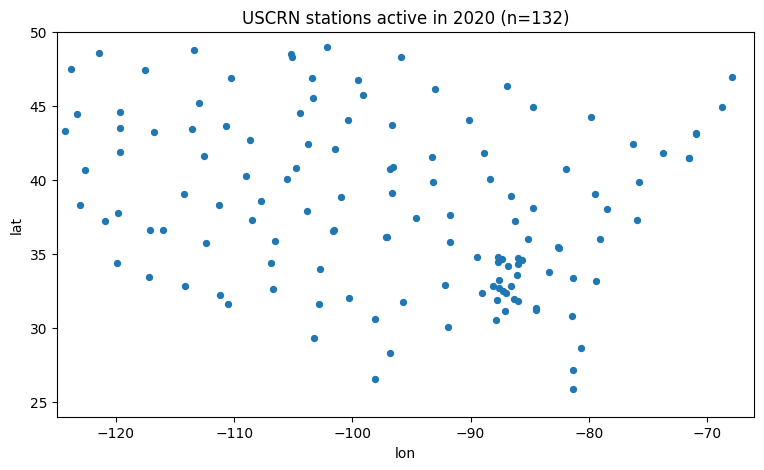

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
stations = tidy.groupby('station_id')[['lon', 'lat']].first()
ax.scatter(stations['lon'], stations['lat'], s=18)
ax.set_xlim(lonmin, lonmax); ax.set_ylim(latmin, latmax)
ax.set_title(f'USCRN stations active in {YEAR} (n={len(stations)})')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.show()


% missing per variable:
precip     1.4
rh        13.0
t_air      0.2
t_soil    12.3
sm        25.8
dtype: float64


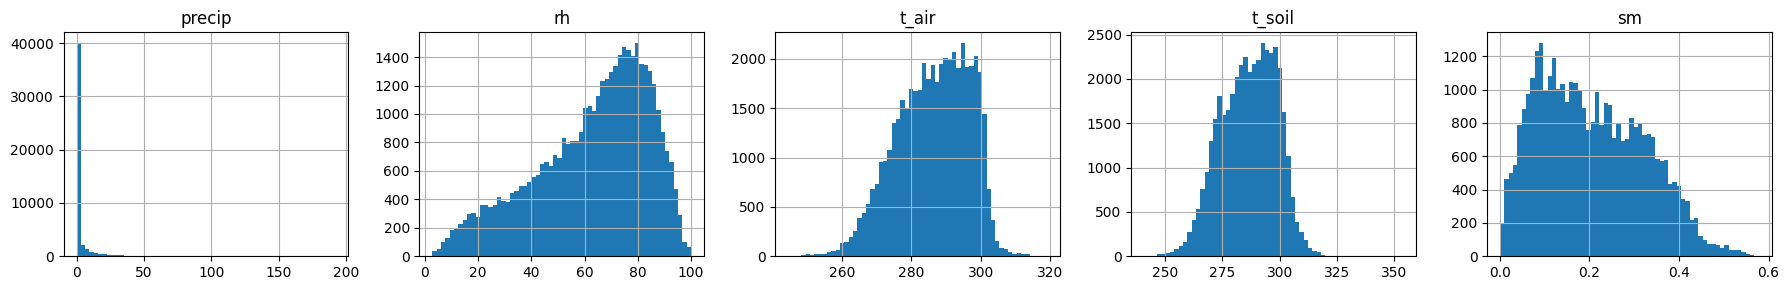

In [10]:
missing = tidy[['precip','rh','t_air','t_soil','sm']].isna().mean().mul(100).round(1)
print('% missing per variable:'); print(missing)

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, var in zip(axes, ['precip','rh','t_air','t_soil','sm']):
    tidy[var].dropna().hist(bins=60, ax=ax)
    ax.set_title(var)
plt.tight_layout(); plt.show()
